# Hex-grain siting: the ranking, and why covariates do not sharpen it

Two results, drawn on one region — the Klamath Mountains / California High North Coast Range, 198
res-5 hexes.

1. **Ignition likelihood is rankable.** The persistence baseline (a hex's own natural + human
   ignition history, k=7, from seasons strictly before the target) orders hexes well enough that 30%
   of a held-out season's starts fall under 6% of the ground.
2. **Fuel-state covariates do not improve that ranking**, because their variation is between places
   rather than between years — and place is what persistence already encodes.

Figures are rendered by [`../src/w6_visuals.py`](../src/w6_visuals.py).

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image

sys.path.insert(0, "../src")
import w6_visuals as wv
from config import ProjectConfig

cfg = ProjectConfig()
DATA = cfg.data
IMG = Path("../img")
IMG.mkdir(exist_ok=True)

ndvi = pd.read_parquet(DATA / "hex_season_ndvi.parquet")
grid = pd.read_parquet(DATA / "hex_grid_res5.parquet")
print(f"{len(ndvi):,} hex-seasons | {ndvi['hex_id'].nunique():,} hexes "
      f"| {ndvi['season_year'].min()}-{ndvi['season_year'].max()} "
      f"| seasons: {sorted(ndvi['season'].unique())}")

55,923 hex-seasons | 2,663 hexes | 2000-2020 | seasons: ['JJA']


## Triage tiers from the persistence ranking

Rank every hex by predicted ignitions, then cut the ranking where cumulative captured starts reach
30%, 60% and 90%. Tiers defined by capture rather than by a fixed ground budget, so the cut points
report what each increment buys.

          region: Klamath Mountains/California High North Coast Range
           n_hex: 198
     target_year: 2020
   capture_tiers: (0.3, 0.6, 0.9)
  hexes_per_tier: [12, 57, 154]
     ground_frac: [0.06060606060606061, 0.2878787878787879, 0.7777777777777778]
            lift: [4.949999999999999, 2.0842105263157893, 1.1571428571428573]
   actual_starts: 366
             rho: 0.502
        out_path: ../img/w6_siting_glance.png


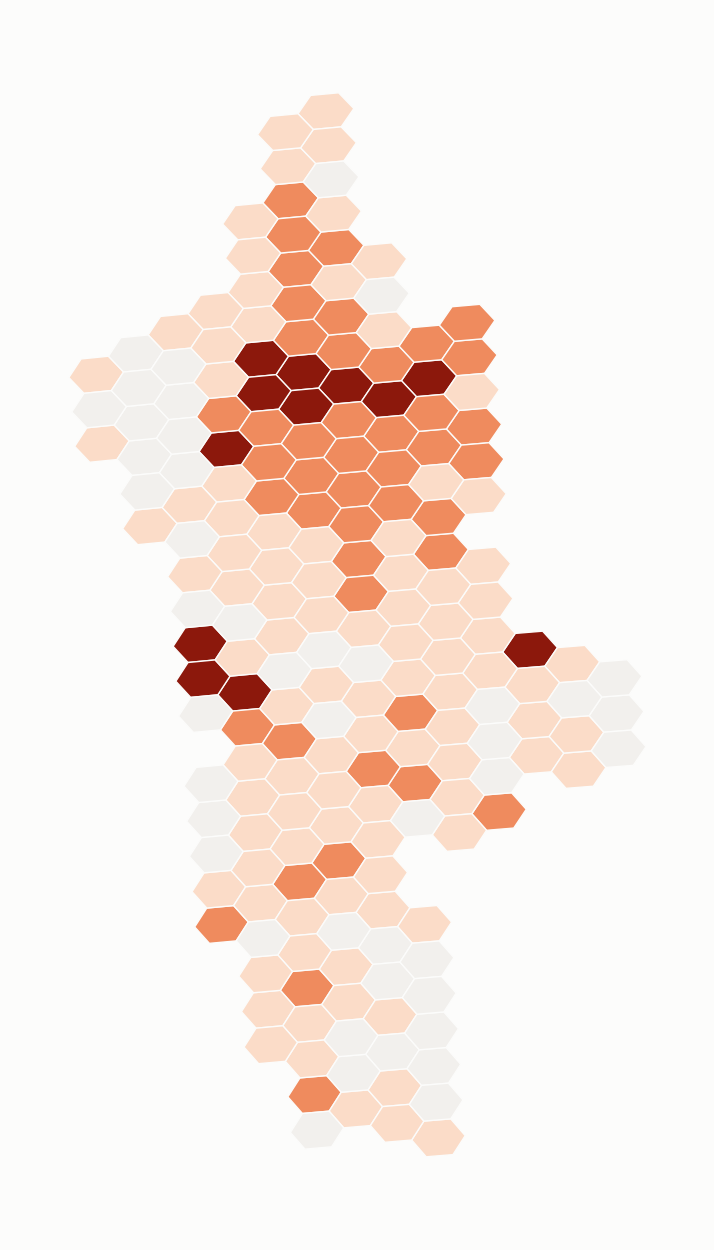

In [2]:
panel = pd.read_parquet(DATA / "hex_panel_modelling.parquet")

site = wv.plot_siting_glance(panel, grid, IMG / "w6_siting_glance.png")
for k, v in site.items():
    print(f"  {k:>14}: {v:.3f}" if isinstance(v, float) else f"  {k:>14}: {v}")

Image(filename=site["out_path"], width=760)

**Returns diminish sharply across the ranking.**

| tier | starts caught | ground | lift over random |
| --- | --- | --- | --- |
| deep | 30% | 6.1% | **4.95x** |
| mid | 60% | 28.8% | 2.08x |
| pale | 90% | 77.8% | 1.16x |

The top 6% of ground carries five times its proportional share of ignitions. Reaching 90% capture
requires 77.8% of the region at a 1.16x lift — near-uniform treatment.

Tiers are discrete rather than continuously shaded because the W6 modelling found ignition acts as a
**gate rather than a dial**: escape probability *per ignition* falls with count, and 49% of large
fires came from hexes with a single ignition. Rank order is supported; graded intensity is not.

## Scoring the ranking against the held-out season

                region: Klamath Mountains/California High North Coast Range
                 n_hex: 198
           target_year: 2020
               n_sited: 40
                  hits: 35
       false_positives: 5
                misses: 89
        correct_passes: 69
             precision: 0.875
        starts_capture: 0.497
                  lift: 2.486
                   rho: 0.502
                colors: {'hit': '#4a4a48', 'false_positive': '#4f86c6', 'miss': '#c2400f', 'correct_pass': '#eeece8'}
              out_path: ../img/w6_siting_vs_burn.png


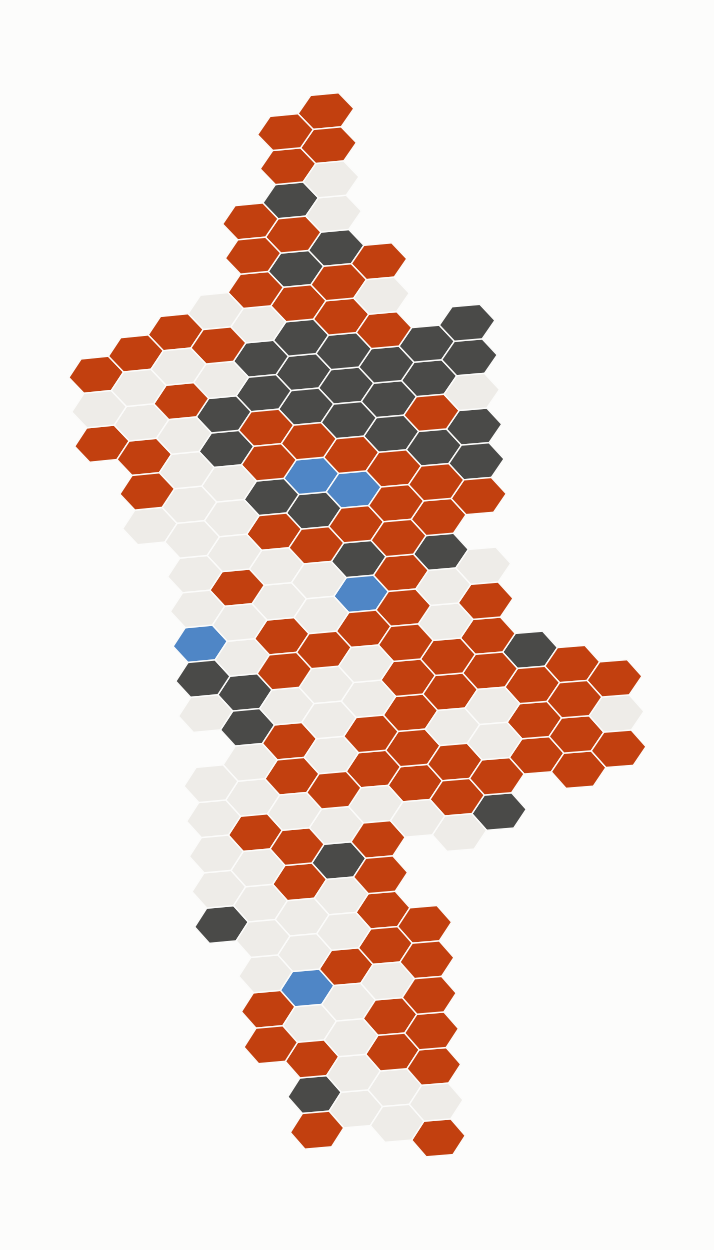

In [3]:
check = wv.plot_siting_vs_burn(panel, grid, IMG / "w6_siting_vs_burn.png")
for k, v in check.items():
    print(f"  {k:>20}: {v:.3f}" if isinstance(v, float) else f"  {k:>20}: {v}")

Image(filename=check["out_path"], width=760)

**35 of 40 sited hexes ignited (87.5% precision), capturing 49.7% of starts at a 2.49x lift**,
Spearman +0.50.

Three qualifications:

**High base rate.** 63% of hexes in this region recorded at least one ignition, so precision
overstates the result. Capture — half the starts under a fifth of the ground — is the informative
quantity.

**Ignitions, not acres.** Scored against burned acres the same ranking captures ~5% of the burn.
This reproduces the notebook 13 result at the level of a single region: ignition location is
predictable, burned area in the tail is not (top decile under-predicted 270x).

**No counterfactual.** Whether treating these hexes would reduce burned acres is untestable here.
FPA-FOD records fires that occurred, not fires an intervention prevented.

## NDVI: what the covariate measures

MODIS NDVI indexes vegetation density per hex-season. The two panels are the region's greenest and
brownest years on record (2015, 2011), on a shared color scale.

           region: Klamath Mountains/California High North Coast Range
            n_hex: 198
    greenest_year: 2015
    brownest_year: 2011
    greenest_mean: 0.707
    brownest_mean: 0.580
       year_range: 0.127
       between_sd: 0.100
        within_sd: 0.044
         out_path: ../img/w6_ndvi_map.png


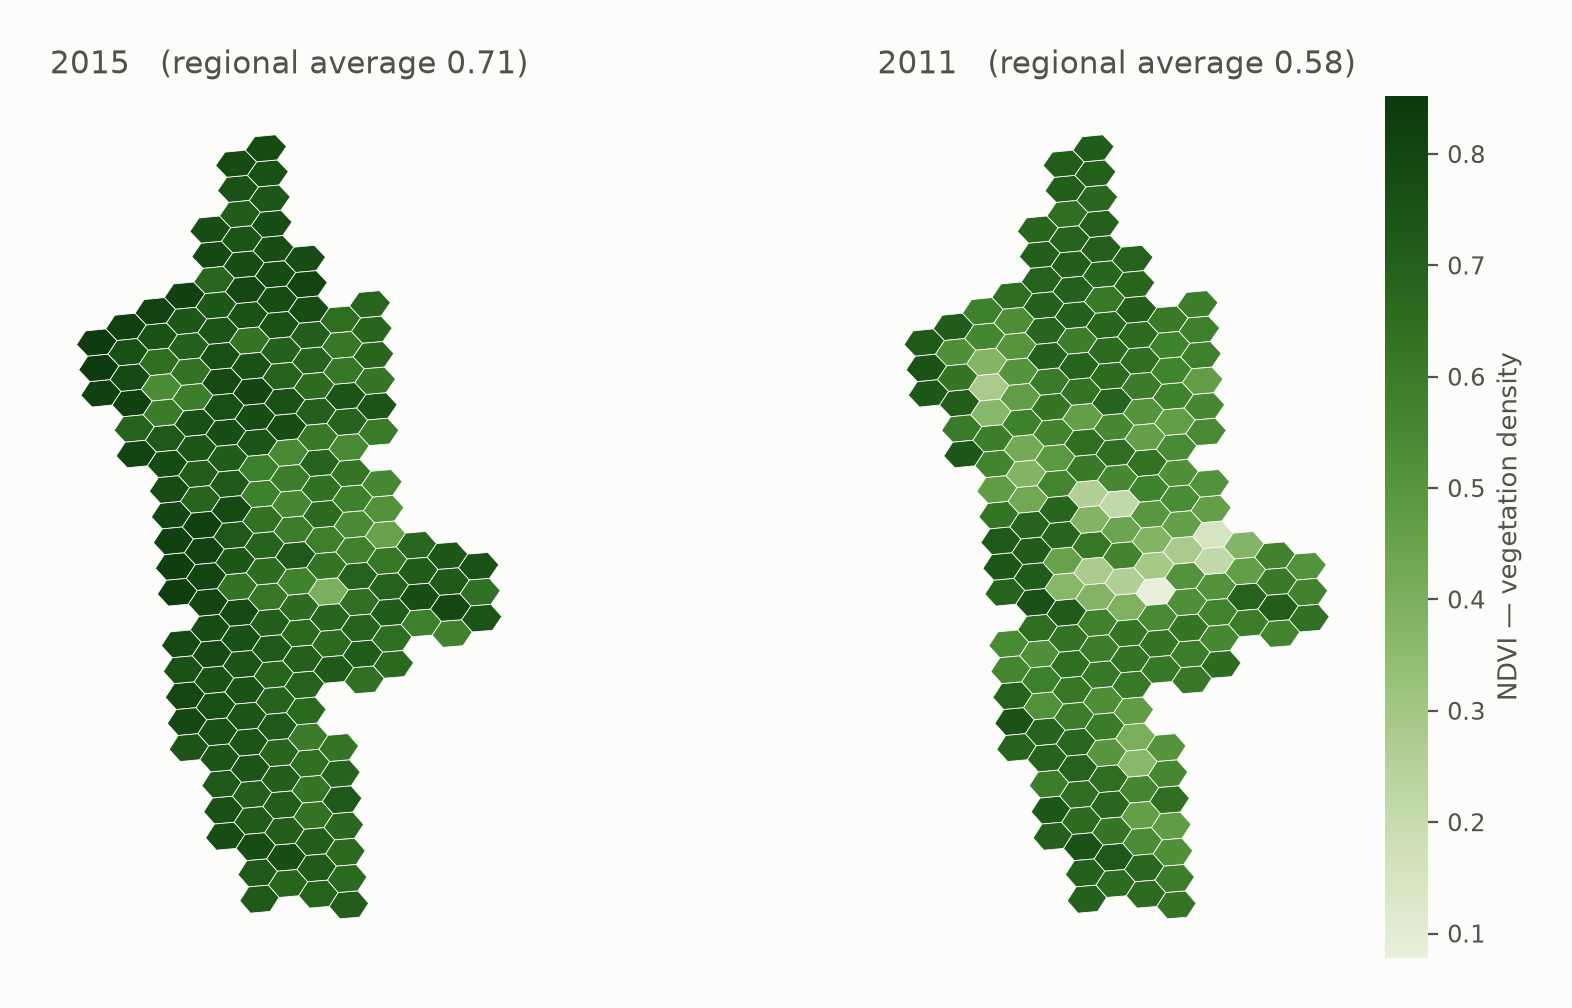

In [4]:
map_info = wv.plot_ndvi_map(ndvi, grid, IMG / "w6_ndvi_map.png")
for k, v in map_info.items():
    print(f"  {k:>15}: {v:.3f}" if isinstance(v, float) else f"  {k:>15}: {v}")

Image(filename=map_info["out_path"], width=980)

**NDVI resolves terrain, not conditions.** The internal pattern is stable — dark ridges and a pale
interior valley in both panels — while the regional mean shifts 0.71 to 0.58 between the extreme
years of a 21-year record. Between-hex spread within a single year exceeds the year-to-year shift.

## Both layers, split-half across a decade gap

Four maps: ignitions and NDVI, each in two non-overlapping eras (through 2005, 2015 onward). Left-right
agreement is therefore across a ten-year gap.

Ignitions are per-season rates, not totals — the eras span different numbers of years.

              region: Klamath Mountains/California High North Coast Range
               n_hex: 198
    fires_split_half: 0.579
     ndvi_split_half: 0.916
         cross_layer: -0.267
           early_era: through 2005
            late_era: 2015 onward
            out_path: ../img/w6_persistence_pair.png


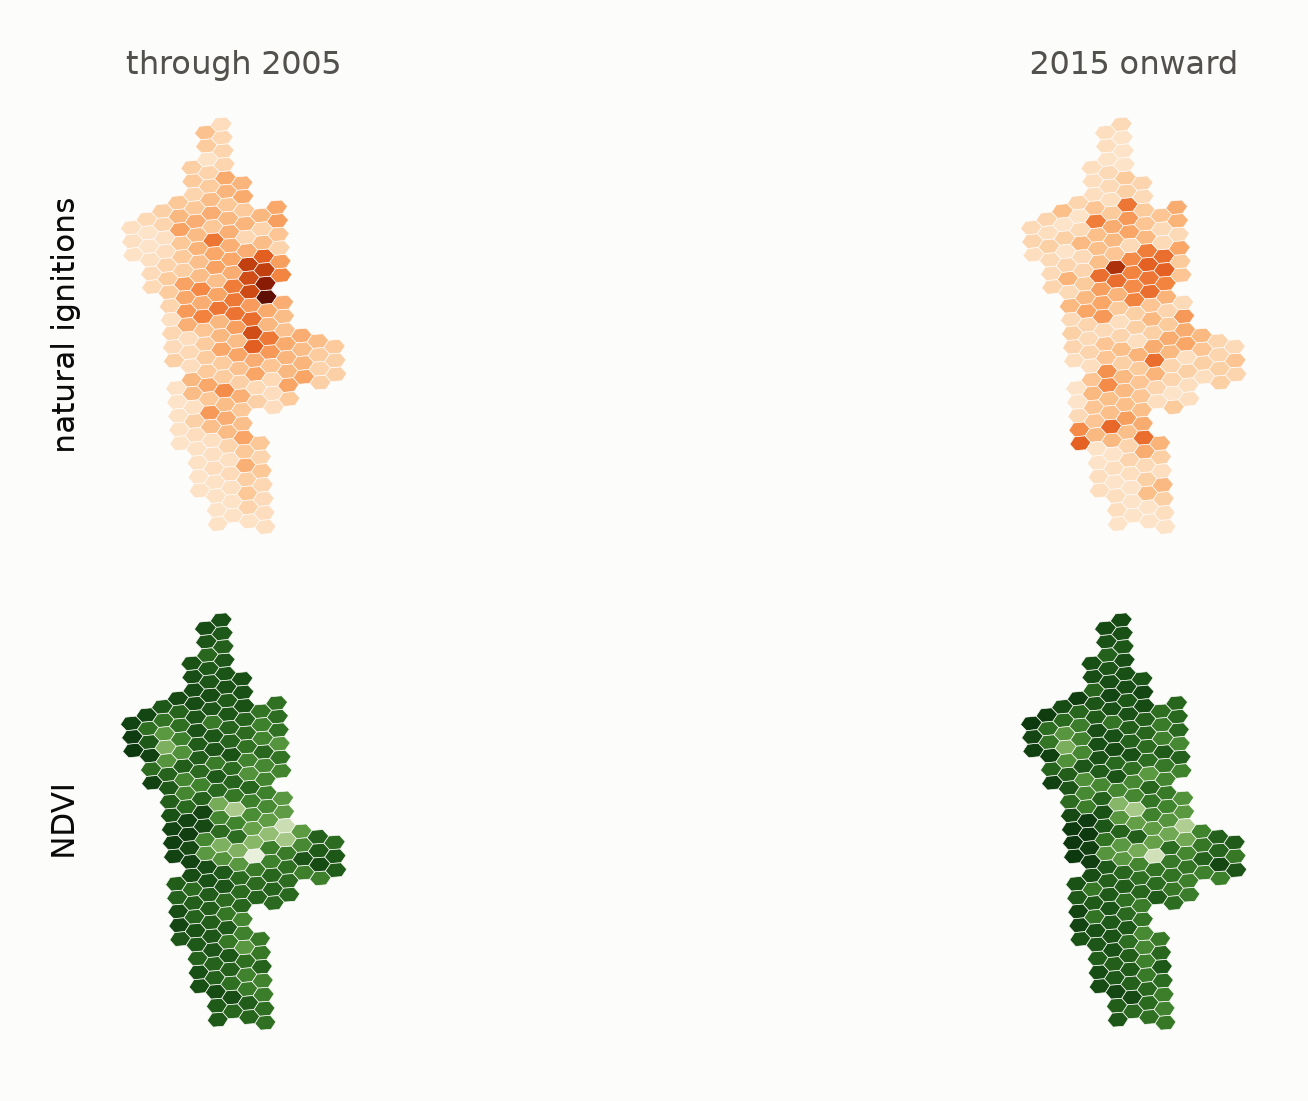

In [5]:
pair = wv.plot_persistence_pair(panel, ndvi, grid, IMG / "w6_persistence_pair.png")
for k, v in pair.items():
    print(f"  {k:>18}: {v:.3f}" if isinstance(v, float) else f"  {k:>18}: {v}")

Image(filename=pair["out_path"], width=1000)

**Both layers persist, and they persist in different patterns.**

- ignitions, split-half Spearman **+0.58** — the persistence baseline, spatially
- NDVI, split-half **+0.92** — more stable than fire
- NDVI x ignitions in this region: **−0.27**

The cross-layer correlation is negative here: densest forest is not where lightning fire concentrates.
(The sign is region-dependent — pooled across the six probe ecoregions the raw correlation is +0.228.)

Together these explain the ablation nulls. Ignition location is stable, so history predicts it.
Greenness is also stable, so it carries the same kind of information — a description of place — which
the ignition history already supplies more directly.

## Variance decomposition

Partition NDVI's variation into between-hex and within-hex components. Year-over-year predictive
signal would require the within-hex term to be comparable to the between-hex term.

In [6]:
stats = wv.ndvi_variance_split(ndvi)
for k, v in stats.items():
    print(f"  {k:>12}: {v:,.4f}" if isinstance(v, float) else f"  {k:>12}: {v:,}")

    between_sd: 0.1323
     within_sd: 0.0478
         ratio: 2.7695
         n_hex: 2,663
       n_years: 21
         n_obs: 55,923


**Between-place spread is ~2.8x the within-hex year-to-year spread.** NDVI is predominantly a
description of location.

This is measured before any model is fit, so it is not attributable to estimator choice or tuning.

## The same decomposition, drawn

One row per hex, sorted by mean NDVI. Left: values as measured. Right: values with each hex's own mean
subtracted.

showing 150 of 2,663 hexes; between/within ratio 2.77x


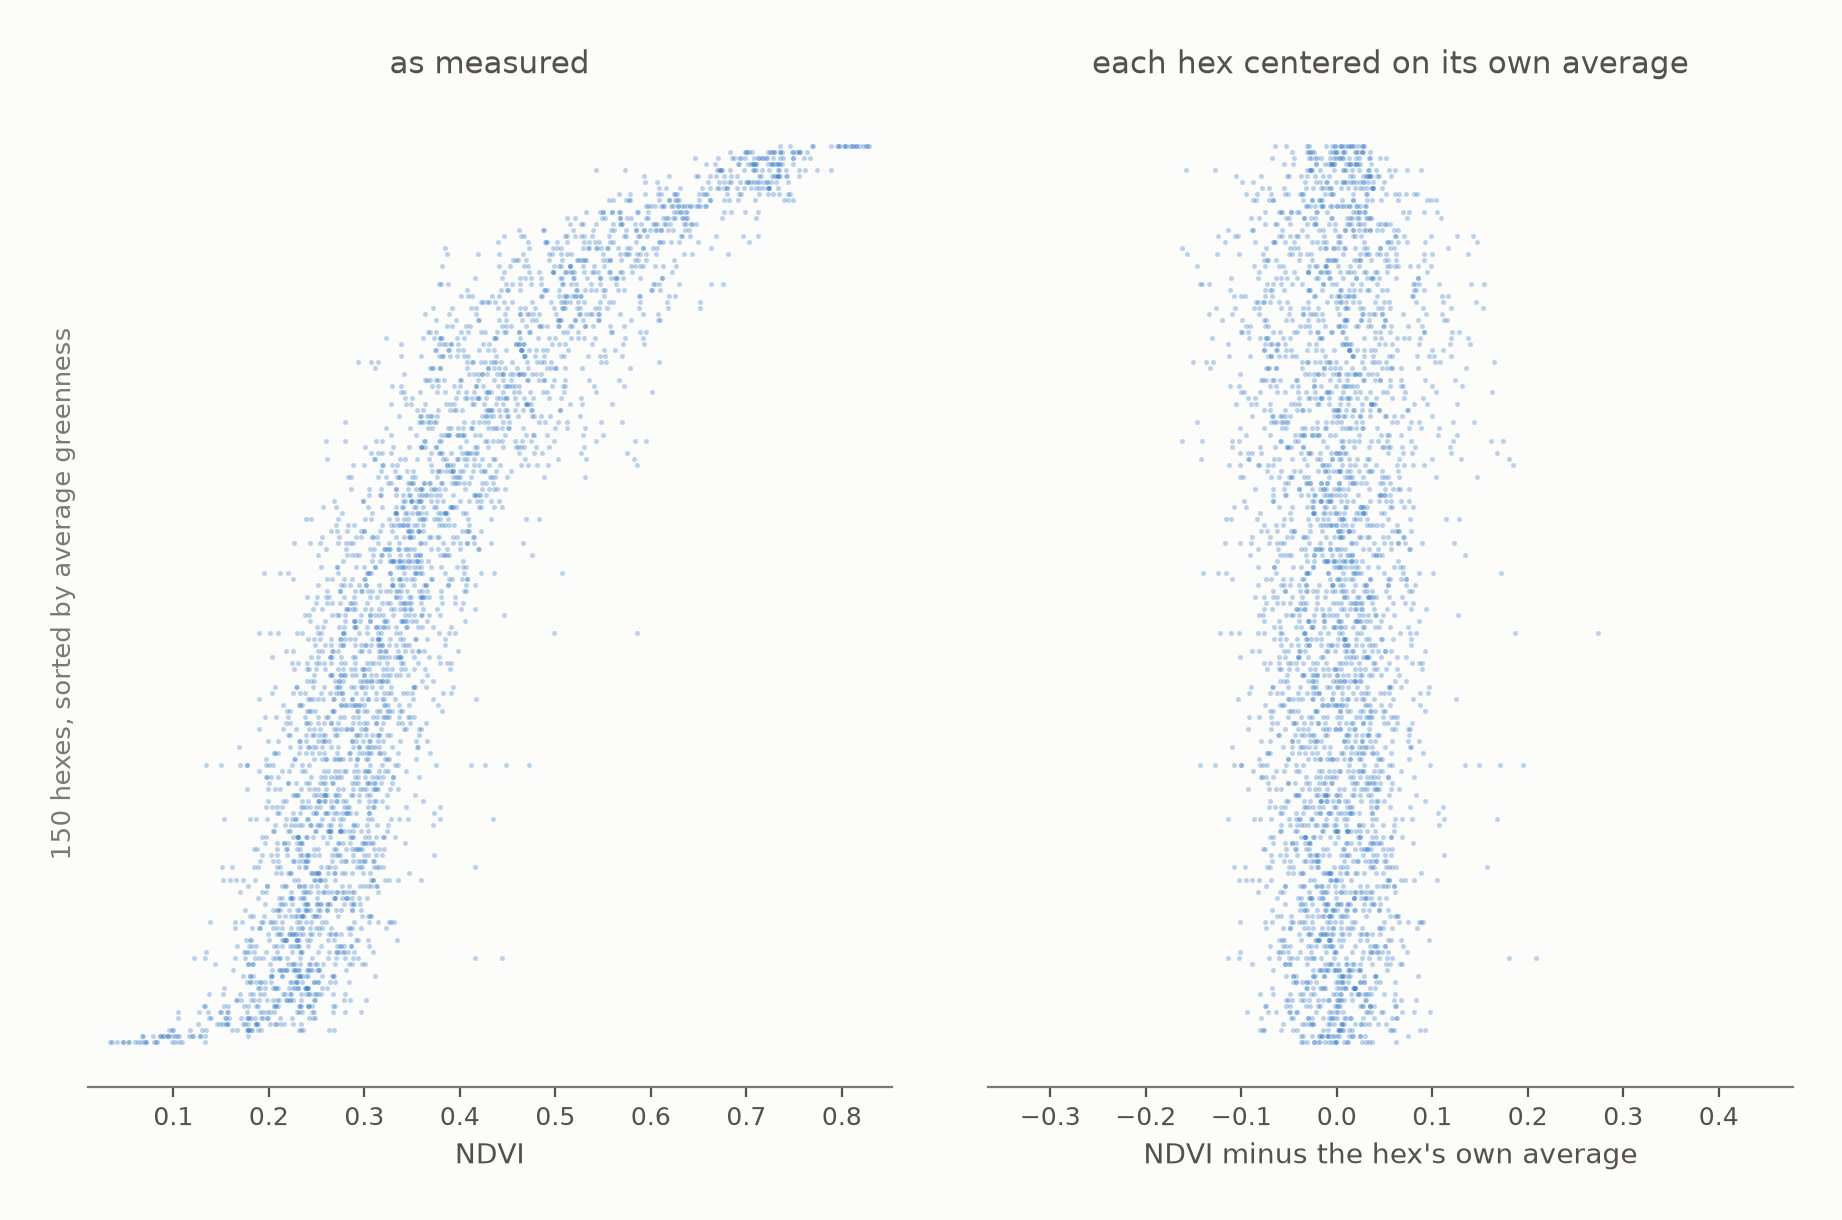

In [7]:
out = IMG / "w6_ndvi_variance.png"
info = wv.plot_ndvi_variance(ndvi, out)
print(f"showing {info['n_shown']} of {info['n_hex']:,} hexes; "
      f"between/within ratio {info['ratio']:.2f}x")

Image(filename=info["out_path"], width=980)

**The vertical structure is between-hex; centering removes nearly all of it.** Values span
0.05–0.85 across hexes and collapse to a narrow band around zero within them. The right panel is the
variation available to a covariate rung after persistence has taken the place effect.

**Scope.** JJA, 2000–2020, six forest ecoregions — the MODIS probe's coverage, and the population the
burned-area covariate gain was measured on.

## Caption values

In [8]:
print(f"between-place sd : {stats['between_sd']:.3f}")
print(f"within-hex sd    : {stats['within_sd']:.3f}")
print(f"ratio            : {stats['ratio']:.1f}x")
print(f"population       : {stats['n_hex']:,} hexes x {stats['n_years']} JJA seasons "
      f"= {stats['n_obs']:,} observations")

between-place sd : 0.132
within-hex sd    : 0.048
ratio            : 2.8x
population       : 2,663 hexes x 21 JJA seasons = 55,923 observations
